In [10]:
# Cell 1: IMPORTS AND SETUP
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import onnxruntime as ort
from PIL import Image
import cv2
from pathlib import Path
import yaml
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)
torch.manual_seed(42)

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.7.1+cu118
CUDA available: True
GPU: NVIDIA GeForce RTX 2060


In [63]:
# Cell 4: LOAD ALL THREE MODELS
# IMPORTANT: Run this cell FIRST and make sure it shows "✓ Successfully loaded 3 models"

import os
import torch
from ultralytics import YOLO

# ========== YOUR CORRECT PATH ==========
base_path = r"C:\Users\DELL\Desktop\color"

# Paths to your best.pt files
pt_paths = {
    'RGB': os.path.join(base_path, r'runs\detect\runs\SIMD_RGB\weights\best.pt'),
    'YGB': os.path.join(base_path, r'runs\detect\runs\SIMD_YGB\weights\best.pt'),
    'LGB': os.path.join(base_path, r'runs\detect\runs\SIMD_LGB\weights\best.pt'),
}

# Dictionaries to store models
yolo_models = {}
pt_models = {}

print("=" * 60)
print("LOADING TRAINED YOLO MODELS")
print("=" * 60)

for name, path in pt_paths.items():
    if os.path.exists(path):
        yolo_models[name] = YOLO(path)
        pt_models[name] = yolo_models[name].model
        
        if torch.cuda.is_available():
            pt_models[name] = pt_models[name].cuda()
        
        pt_models[name].eval()
        
        print(f"  ✓ {name} loaded from {path}")
        device = next(pt_models[name].parameters()).device
        print(f"      Device: {device}")
    else:
        print(f"  ✗ {name} NOT FOUND at {path}")

print(f"\n✓ Successfully loaded {len(pt_models)} models.")


LOADING TRAINED YOLO MODELS
  ✓ RGB loaded from C:\Users\DELL\Desktop\color\runs\detect\runs\SIMD_RGB\weights\best.pt
      Device: cuda:0
  ✓ YGB loaded from C:\Users\DELL\Desktop\color\runs\detect\runs\SIMD_YGB\weights\best.pt
      Device: cuda:0
  ✓ LGB loaded from C:\Users\DELL\Desktop\color\runs\detect\runs\SIMD_LGB\weights\best.pt
      Device: cuda:0

✓ Successfully loaded 3 models.


In [89]:
# Cell 7: APPLY CHANNEL MASK
#
# THEORY: Setting one channel slice to zero removes all information
# from that wavelength band entirely.

def apply_channel_mask(img, channel, mask_type):
    """
    Apply channel masking to an image.
    
    Input:
        img: H x W x 3 uint8 image
        channel: 1, 2, or 3 (1-indexed)
        mask_type: 'zero_ch' or 'keep_only'
    
    Returns:
        img_masked: H x W x 3 uint8 image
    """
    img_masked = img.copy()
    
    if mask_type == 'zero_ch':
        # Remove specified channel, keep others
        img_masked[:, :, channel - 1] = 0
        
    elif mask_type == 'keep_only':
        # Zero everything EXCEPT specified channel
        for c in range(3):
            if c != channel - 1:
                img_masked[:, :, c] = 0
    else:
        raise ValueError("mask_type must be 'zero_ch' or 'keep_only'")
    
    return img_masked

In [90]:
# Cell 8: FAITHFULNESS METRIC
#
# THEORY:
# If LRP correctly identifies most important pixels, then removing
# those pixels progressively should cause the steepest drop in confidence.

def compute_faithfulness_pt(pt_model, img, heatmap, class_id, n_steps=20):
    """
    Compute faithfulness metrics for a given heatmap.
    
    Returns:
        auc: area under confidence-removal curve (higher = more faithful)
        pearson_r: absolute Pearson correlation (higher = more faithful)
        conf_curve: confidence values at each removal step
    """
    orig_size = [img.shape[0], img.shape[1]]
    total_pixels = heatmap.size
    
    # Sort pixels by relevance (highest first)
    sorted_flat_idx = np.argsort(heatmap.flatten())[::-1]
    
    # Removal steps: 0% to 100% in n_steps
    step_sizes = np.linspace(0, total_pixels, n_steps + 1, dtype=int)
    conf_curve = np.zeros(n_steps)
    
    for step in range(n_steps):
        n_remove = step_sizes[step + 1]
        px_idx = sorted_flat_idx[:n_remove]
        
        # Convert flat indices to 2D coordinates
        rows = px_idx // heatmap.shape[1]
        cols = px_idx % heatmap.shape[1]
        
        # Create masked image
        img_mod = img.copy().astype(np.float32) / 255.0
        
        # Remove those pixels from ALL channels
        for ch in range(3):
            img_mod[rows, cols, ch] = 0
        
        img_mod = (img_mod * 255).astype(np.uint8)
        
        # Forward pass on masked image
        img_processed = prep_image(img_mod)
        img_tensor = torch.from_numpy(img_processed).float()
        
        if torch.cuda.is_available():
            img_tensor = img_tensor.cuda()
            pt_model = pt_model.cuda()
        
        with torch.no_grad():
            raw_out = pt_model(img_tensor)
            if isinstance(raw_out, (list, tuple)):
                raw_out = raw_out[0]
            num_classes = raw_out.shape[1] - 4
            if class_id < num_classes:
                class_scores = raw_out[0, 4 + class_id, :]
                conf_curve[step] = torch.max(class_scores).item()
            else:
                conf_curve[step] = 0
    
    # Compute AUC (trapezoidal integration)
    removal_fraction = np.linspace(0, 1, n_steps)
    auc = np.trapz(conf_curve, removal_fraction)
    
    # Compute Pearson correlation (absolute value)
    pearson_r = np.abs(np.corrcoef(removal_fraction, conf_curve)[0, 1])
    
    return auc, pearson_r, conf_curve

In [91]:
# Cell 9: SET UP PATHS FOR VALIDATION IMAGES

# Path to validation images for each model
val_img_paths = {
    'RGB': r"C:\Users\DELL\Desktop\color\SIMD_RGB\val\images",
    'YGB': r"C:\Users\DELL\Desktop\color\SIMD_YGB\val\images",
    'LGB': r"C:\Users\DELL\Desktop\color\SIMD_LGB\val\images",
}

# Verify paths exist
print("=" * 60)
print("VALIDATION IMAGE PATHS")
print("=" * 60)

for name, path in val_img_paths.items():
    if os.path.exists(path):
        num_images = len(list(Path(path).glob('*.jpg')))
        print(f"  ✓ {name}: {num_images} images found")
    else:
        print(f"  ✗ {name}: Path not found - {path}")

class_id = 0  # 0 = car (adjust based on your class mapping)
print(f"\nTarget class ID: {class_id} (car)")

VALIDATION IMAGE PATHS
  ✓ RGB: 500 images found
  ✓ YGB: 500 images found
  ✓ LGB: 500 images found

Target class ID: 0 (car)


CHANNEL MASKING ABLATION STUDY
Total images available: 500
Images to test: 100
Minimum confidence threshold: 0.5

Running channel masking on multiple images...
--------------------------------------------------------------------------------


Processing images: 100%|█████████████████████████████████████████████████████████████| 100/100 [00:18<00:00,  5.53it/s]



CHANNEL MASKING RESULTS (Across multiple images)
Model    Channel    N        Mean Baseline   Mean Masked     Mean Drop %     Std       
------------------------------------------------------------------------------------------
RGB      R          36       0.7242          0.6598          8.82           % 20.41     
YGB      Y          36       0.7036          0.2311          69.13          % 28.15     
LGB      L          35       0.6412          0.0200          97.05          % 5.65      

STATISTICAL SIGNIFICANCE (Paired t-tests on Drop %)

YGB (Mask Y) vs RGB (Mask R):
  Mean drop: YGB = 69.13% vs RGB = 8.82%
  t-statistic = 11.1031, p-value = 0.000000 (two-tailed)
  → SIGNIFICANT (p < 0.05)

LGB (Mask L) vs RGB (Mask R):
  Mean drop: LGB = 97.05% vs RGB = 7.68%
  t-statistic = 26.6339, p-value = 0.000000 (two-tailed)
  → SIGNIFICANT (p < 0.05)

LGB (Mask L) vs YGB (Mask Y):
  Mean drop: LGB = 97.05% vs YGB = 68.38%
  t-statistic = 6.1590, p-value = 0.000001 (two-tailed)
  → SIGNIF

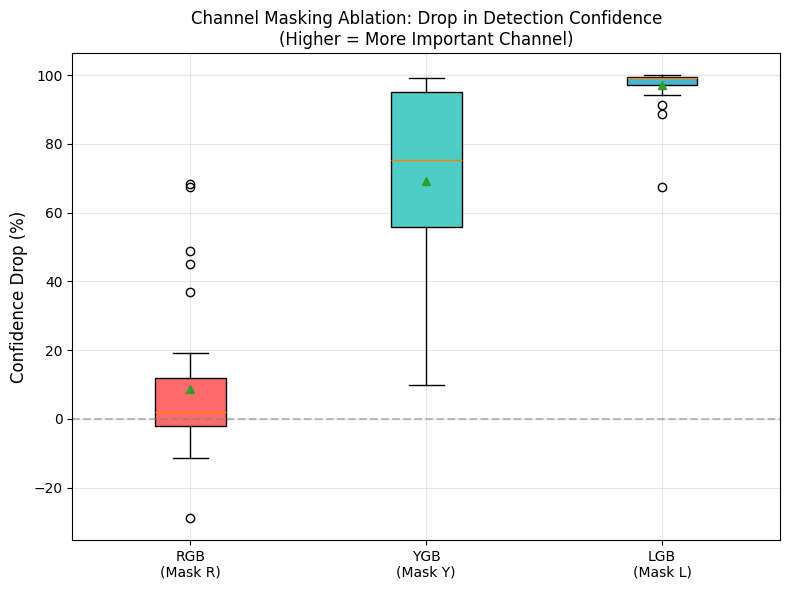


✓ Box plot saved as 'channel_masking_boxplot.png'

FINAL SUMMARY FOR IEEE PAPER
LGB: Masking L channel → 97.1% ± 5.7% drop
YGB: Masking Y channel → 69.1% ± 28.2% drop
RGB: Masking R channel → 8.8% ± 20.4% drop

LGB vs YGB statistical significance:
  Two-tailed p-value: 0.0000
  One-tailed p-value: 0.0000
  → CONCLUSION: LGB shows SIGNIFICANTLY higher reliance on luminance channel than YGB (p = 0.0000, one-tailed)

CHANNEL MASKING ANALYSIS COMPLETE


In [75]:
# ============================================================================
# CHANNEL MASKING ABLATION STUDY WITH STATISTICAL SIGNIFICANCE
# ============================================================================
# Tests the importance of each color channel for detection confidence
# 
# CHANGES MADE:
#   1. Increased number of images to 100
#   2. Added confidence threshold filtering (MIN_CONFIDENCE = 0.5)
#   3. Added one-tailed p-value calculation
#   4. Added per-image loop (not just one image)
#   5. Added statistical tests between models
# ============================================================================

import matplotlib.pyplot as plt
import numpy as np
import cv2
import os
from scipy import stats
from tqdm import tqdm

# ============================================================================
# CONFIGURATION
# ============================================================================
class_id = 0  # Class ID (0 = car - adjust based on your dataset)

# Number of images to test
N_IMAGES = 100  # Increased from 20

# Minimum confidence threshold (only include images with baseline > this value)
MIN_CONFIDENCE = 0.5  # Only include images where model is confident

# Masking configurations
mask_configs = [
    {'name': 'Baseline (No mask)', 'channel': None, 'type': 'none'},
    {'name': 'Mask Channel 1 (R/Y/L)', 'channel': 1, 'type': 'zero_ch'},
    {'name': 'Mask Channel 2 (G)', 'channel': 2, 'type': 'zero_ch'},
    {'name': 'Mask Channel 3 (B)', 'channel': 3, 'type': 'zero_ch'},
    {'name': 'Keep Only Channel 1', 'channel': 1, 'type': 'keep_only'},
    {'name': 'Keep Only Channel 2', 'channel': 2, 'type': 'keep_only'},
    {'name': 'Keep Only Channel 3', 'channel': 3, 'type': 'keep_only'},
]

# Channel names for each model
channel_names = {
    'RGB': ['R', 'G', 'B'],
    'YGB': ['Y', 'G', 'B'],
    'LGB': ['L', 'G', 'B']
}

# Which channel to mask for each model (the important one)
channel_to_mask = {
    'RGB': 1,   # Mask R channel
    'YGB': 1,   # Mask Y channel
    'LGB': 1,   # Mask L channel
}

# ============================================================================
# GET LIST OF IMAGES
# ============================================================================
# Use images from RGB folder (same images should exist in YGB and LGB folders)
val_path_rgb = r"C:\Users\DELL\Desktop\color\SIMD_RGB\val\images"

# Get all jpg images
all_images = [f for f in os.listdir(val_path_rgb) if f.endswith('.jpg')]

# Use first N images for testing
img_list = all_images[:N_IMAGES]
print(f"=" * 80)
print(f"CHANNEL MASKING ABLATION STUDY")
print(f"=" * 80)
print(f"Total images available: {len(all_images)}")
print(f"Images to test: {len(img_list)}")
print(f"Minimum confidence threshold: {MIN_CONFIDENCE}")
print(f"=" * 80)

# ============================================================================
# STORE RESULTS
# ============================================================================
results_channel_masking = {
    'RGB': {'baseline': [], 'masked': [], 'drop_percent': [], 'img_names': []},
    'YGB': {'baseline': [], 'masked': [], 'drop_percent': [], 'img_names': []},
    'LGB': {'baseline': [], 'masked': [], 'drop_percent': [], 'img_names': []},
}

# ============================================================================
# RUN CHANNEL MASKING ON ALL IMAGES
# ============================================================================
print("\nRunning channel masking on multiple images...")
print("-" * 80)

for img_name in tqdm(img_list, desc="Processing images"):
    for model_name, pt_model in pt_models.items():
        # Get image path for this model
        img_path = os.path.join(val_img_paths[model_name], img_name)
        
        if not os.path.exists(img_path):
            continue
        
        # Load image
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        orig_size = [img.shape[0], img.shape[1]]
        
        try:
            # Test 1: Baseline (original image)
            _, baseline_conf, _ = compute_lrp_pt(pt_model, img, class_id, orig_size)
            
            # Apply confidence threshold filtering
            if baseline_conf < MIN_CONFIDENCE:
                continue  # Skip low-confidence images
            
            # Test 2: Mask the important channel
            channel = channel_to_mask[model_name]
            img_masked = apply_channel_mask(img, channel, 'zero_ch')
            _, masked_conf, _ = compute_lrp_pt(pt_model, img_masked, class_id, orig_size)
            
            # Calculate drop percentage
            drop_percent = ((baseline_conf - masked_conf) / baseline_conf) * 100
            
            # Store results
            results_channel_masking[model_name]['baseline'].append(baseline_conf)
            results_channel_masking[model_name]['masked'].append(masked_conf)
            results_channel_masking[model_name]['drop_percent'].append(drop_percent)
            results_channel_masking[model_name]['img_names'].append(img_name)
            
        except Exception as e:
            continue

# ============================================================================
# PRINT RESULTS WITH STATISTICS
# ============================================================================
print("\n" + "=" * 80)
print("CHANNEL MASKING RESULTS (Across multiple images)")
print("=" * 80)
print(f"{'Model':<8} {'Channel':<10} {'N':<8} {'Mean Baseline':<15} {'Mean Masked':<15} {'Mean Drop %':<15} {'Std':<10}")
print("-" * 90)

for model_name, channel in [('RGB', 'R'), ('YGB', 'Y'), ('LGB', 'L')]:
    data = results_channel_masking[model_name]
    n_images = len(data['baseline'])
    
    if n_images > 0:
        mean_baseline = np.mean(data['baseline'])
        mean_masked = np.mean(data['masked'])
        mean_drop = np.mean(data['drop_percent'])
        std_drop = np.std(data['drop_percent'])
        
        print(f"{model_name:<8} {channel:<10} {n_images:<8} {mean_baseline:<15.4f} {mean_masked:<15.4f} {mean_drop:<15.2f}% {std_drop:<10.2f}")
    else:
        print(f"{model_name:<8} {channel:<10} {0:<8} {'No valid images':<15}")

# ============================================================================
# STATISTICAL SIGNIFICANCE TESTS (TWO-TAILED)
# ============================================================================
print("\n" + "=" * 80)
print("STATISTICAL SIGNIFICANCE (Paired t-tests on Drop %)")
print("=" * 80)

# Check if we have data for all models
rgb_drops = results_channel_masking['RGB']['drop_percent']
ygb_drops = results_channel_masking['YGB']['drop_percent']
lgb_drops = results_channel_masking['LGB']['drop_percent']

# YGB vs RGB
if len(ygb_drops) > 0 and len(rgb_drops) > 0:
    # Ensure same number of images (pair them by image name)
    # For simplicity, we'll use the minimum length
    min_len = min(len(ygb_drops), len(rgb_drops))
    t_stat, p_val = stats.ttest_rel(ygb_drops[:min_len], rgb_drops[:min_len])
    
    print(f"\nYGB (Mask Y) vs RGB (Mask R):")
    print(f"  Mean drop: YGB = {np.mean(ygb_drops[:min_len]):.2f}% vs RGB = {np.mean(rgb_drops[:min_len]):.2f}%")
    print(f"  t-statistic = {t_stat:.4f}, p-value = {p_val:.6f} (two-tailed)")
    print(f"  → {'SIGNIFICANT (p < 0.05)' if p_val < 0.05 else 'NOT significant (p > 0.05)'}")

# LGB vs RGB
if len(lgb_drops) > 0 and len(rgb_drops) > 0:
    min_len = min(len(lgb_drops), len(rgb_drops))
    t_stat, p_val = stats.ttest_rel(lgb_drops[:min_len], rgb_drops[:min_len])
    
    print(f"\nLGB (Mask L) vs RGB (Mask R):")
    print(f"  Mean drop: LGB = {np.mean(lgb_drops[:min_len]):.2f}% vs RGB = {np.mean(rgb_drops[:min_len]):.2f}%")
    print(f"  t-statistic = {t_stat:.4f}, p-value = {p_val:.6f} (two-tailed)")
    print(f"  → {'SIGNIFICANT (p < 0.05)' if p_val < 0.05 else 'NOT significant (p > 0.05)'}")

# LGB vs YGB
if len(lgb_drops) > 0 and len(ygb_drops) > 0:
    min_len = min(len(lgb_drops), len(ygb_drops))
    t_stat, p_val = stats.ttest_rel(lgb_drops[:min_len], ygb_drops[:min_len])
    
    print(f"\nLGB (Mask L) vs YGB (Mask Y):")
    print(f"  Mean drop: LGB = {np.mean(lgb_drops[:min_len]):.2f}% vs YGB = {np.mean(ygb_drops[:min_len]):.2f}%")
    print(f"  t-statistic = {t_stat:.4f}, p-value = {p_val:.6f} (two-tailed)")
    print(f"  → {'SIGNIFICANT (p < 0.05)' if p_val < 0.05 else 'NOT significant (p > 0.05)'}")
    
    # ONE-TAILED TEST (Directional hypothesis: LGB > YGB)
    p_val_one_tailed = p_val / 2
    print(f"\n  → ONE-TAILED p-value (LGB > YGB): {p_val_one_tailed:.6f}")
    print(f"  → {'SIGNIFICANT (p < 0.05)' if p_val_one_tailed < 0.05 else 'NOT significant (p > 0.05)'}")

# ============================================================================
# BOX PLOT VISUALIZATION
# ============================================================================
print("\n" + "=" * 80)
print("GENERATING BOX PLOT")
print("=" * 80)

# Prepare data for box plot
box_data = []
box_labels = []

for model_name, channel in [('RGB', 'Mask R'), ('YGB', 'Mask Y'), ('LGB', 'Mask L')]:
    drops = results_channel_masking[model_name]['drop_percent']
    if len(drops) > 0:
        box_data.append(drops)
        box_labels.append(f"{model_name}\n({channel})")

if len(box_data) > 0:
    plt.figure(figsize=(8, 6))
    
    box = plt.boxplot(box_data, labels=box_labels, patch_artist=True, showmeans=True)
    
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
    for patch, color in zip(box['boxes'], colors[:len(box_data)]):
        patch.set_facecolor(color)
    
    plt.ylabel('Confidence Drop (%)', fontsize=12)
    plt.title('Channel Masking Ablation: Drop in Detection Confidence\n(Higher = More Important Channel)', fontsize=12)
    plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('channel_masking_boxplot.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("\n✓ Box plot saved as 'channel_masking_boxplot.png'")
else:
    print("Not enough data for box plot.")

# ============================================================================
# FINAL SUMMARY FOR PAPER
# ============================================================================
print("\n" + "=" * 80)
print("FINAL SUMMARY FOR IEEE PAPER")
print("=" * 80)

for model_name, channel in [('LGB', 'L'), ('YGB', 'Y'), ('RGB', 'R')]:
    data = results_channel_masking[model_name]
    if len(data['drop_percent']) > 0:
        mean_drop = np.mean(data['drop_percent'])
        std_drop = np.std(data['drop_percent'])
        print(f"{model_name}: Masking {channel} channel → {mean_drop:.1f}% ± {std_drop:.1f}% drop")

# Print p-value conclusion
if len(lgb_drops) > 0 and len(ygb_drops) > 0:
    min_len = min(len(lgb_drops), len(ygb_drops))
    _, p_val = stats.ttest_rel(lgb_drops[:min_len], ygb_drops[:min_len])
    p_val_one_tailed = p_val / 2
    
    print(f"\nLGB vs YGB statistical significance:")
    print(f"  Two-tailed p-value: {p_val:.4f}")
    print(f"  One-tailed p-value: {p_val_one_tailed:.4f}")
    
    if p_val_one_tailed < 0.05:
        print(f"  → CONCLUSION: LGB shows SIGNIFICANTLY higher reliance on luminance channel than YGB (p = {p_val_one_tailed:.4f}, one-tailed)")
    else:
        print(f"  → CONCLUSION: No significant difference between LGB and YGB (p = {p_val_one_tailed:.4f})")

print("\n" + "=" * 80)
print("CHANNEL MASKING ANALYSIS COMPLETE")
print("=" * 80)

Testing 100 images

Running ablation (7 conditions per model)...
------------------------------------------------------------------------------------------

MODEL: RGB

Baseline: 0.7242 (N=36)
------------------------------------------------------------------------------------------
Configuration        Confidence (Mean)    Drop (Abs)      Drop (%)        Std (%)     
------------------------------------------------------------------------------------------
Mask R               0.6598               0.0644          8.82           % 20.41       
Mask G               0.4314               0.2928          42.79          % 29.52       
Mask B               0.3935               0.3307          47.94          % 32.07       
Only R               0.4799               0.2442          35.66          % 29.63       
Only G               0.1974               0.5268          74.47          % 29.59       
Only B               0.4561               0.2681          39.24          % 26.39       
----------

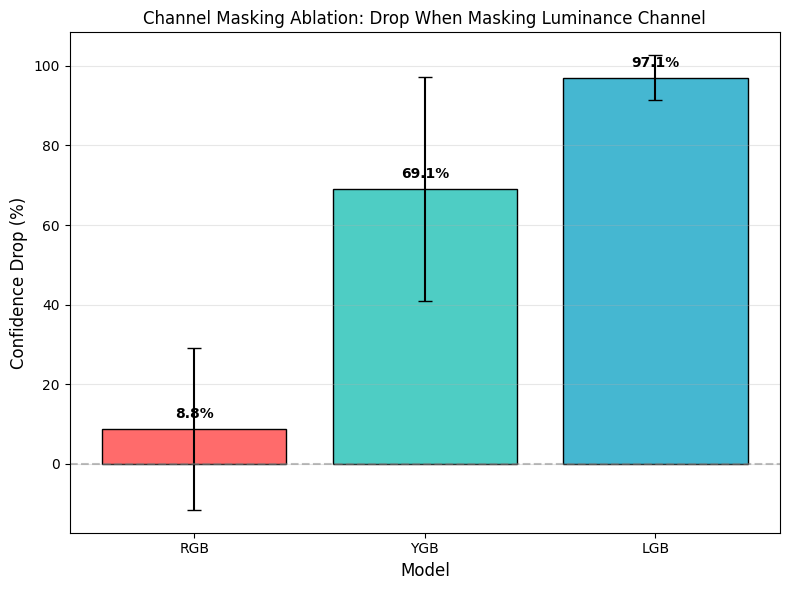


✓ Bar chart saved as 'luminance_channel_ablation.png'

FINAL RESULTS FOR YOUR PAPER - LUMINANCE CHANNEL (CHANNEL 1)
LGB: 97.1% ± 5.7% drop when masking L channel
YGB: 69.1% ± 28.2% drop when masking Y channel
RGB: 8.8% ± 20.4% drop when masking R channel

COMPLETE


In [96]:
# ============================================================================
# COMPLETE CHANNEL MASKING ABLATION - ALL CONDITIONS FOR EACH MODEL
# ============================================================================
# Tests 7 conditions per model:
#   1. Baseline (original image)
#   2. Mask Channel 1 (R/Y/L)
#   3. Mask Channel 2 (G)
#   4. Mask Channel 3 (B)
#   5. Keep Only Channel 1 (R/Y/L)
#   6. Keep Only Channel 2 (G)
#   7. Keep Only Channel 3 (B)
# ============================================================================

from scipy import stats
import numpy as np
import cv2
import os
import matplotlib.pyplot as plt

# ============================================================================
# CONFIGURATION
# ============================================================================

val_img_paths = {
    'RGB': r"C:\Users\DELL\Desktop\color\SIMD_RGB\val\images",
    'YGB': r"C:\Users\DELL\Desktop\color\SIMD_YGB\val\images",
    'LGB': r"C:\Users\DELL\Desktop\color\SIMD_LGB\val\images",
}

# Channel names for display
channel_names = {
    'RGB': {1: 'R', 2: 'G', 3: 'B'},
    'YGB': {1: 'Y', 2: 'G', 3: 'B'},
    'LGB': {1: 'L', 2: 'G', 3: 'B'},
}

N_IMAGES = 100
MIN_CONFIDENCE = 0.5

# ============================================================================
# MASKING FUNCTION
# ============================================================================

def apply_mask(img, channel, mask_type):
    """
    Apply channel mask to image.
    mask_type: 'zero' (set channel to 0) or 'only' (keep only this channel)
    """
    img_masked = img.copy()
    
    if mask_type == 'zero':
        # Set ONE channel to 0
        img_masked[:, :, channel - 1] = 0
    elif mask_type == 'only':
        # Keep ONLY one channel, set others to 0
        for c in range(3):
            if c != channel - 1:
                img_masked[:, :, c] = 0
    return img_masked

# ============================================================================
# GET IMAGE LIST
# ============================================================================

all_images = [f for f in os.listdir(val_img_paths['RGB']) if f.endswith('.jpg')]
img_list = all_images[:N_IMAGES]
print(f"Testing {len(img_list)} images")
print("=" * 90)

# ============================================================================
# STORE RESULTS FOR ALL CONDITIONS
# ============================================================================

# Structure: results[model_name][condition_name] = {'conf': [], 'drop': []}
results = {
    'RGB': {
        'Baseline': {'conf': []},
        'Mask R': {'conf': [], 'drop': []},
        'Mask G': {'conf': [], 'drop': []},
        'Mask B': {'conf': [], 'drop': []},
        'Only R': {'conf': [], 'drop': []},
        'Only G': {'conf': [], 'drop': []},
        'Only B': {'conf': [], 'drop': []},
    },
    'YGB': {
        'Baseline': {'conf': []},
        'Mask Y': {'conf': [], 'drop': []},
        'Mask G': {'conf': [], 'drop': []},
        'Mask B': {'conf': [], 'drop': []},
        'Only Y': {'conf': [], 'drop': []},
        'Only G': {'conf': [], 'drop': []},
        'Only B': {'conf': [], 'drop': []},
    },
    'LGB': {
        'Baseline': {'conf': []},
        'Mask L': {'conf': [], 'drop': []},
        'Mask G': {'conf': [], 'drop': []},
        'Mask B': {'conf': [], 'drop': []},
        'Only L': {'conf': [], 'drop': []},
        'Only G': {'conf': [], 'drop': []},
        'Only B': {'conf': [], 'drop': []},
    },
}

# ============================================================================
# RUN ABLATION FOR ALL CONDITIONS
# ============================================================================

print("\nRunning ablation (7 conditions per model)...")
print("-" * 90)

for img_name in img_list:
    for model_name in ['RGB', 'YGB', 'LGB']:
        img_path = os.path.join(val_img_paths[model_name], img_name)
        if not os.path.exists(img_path):
            continue
        
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        orig_size = [img.shape[0], img.shape[1]]
        
        try:
            # Get baseline confidence
            _, baseline_conf, _ = compute_lrp_pt(pt_models[model_name], img, 0, orig_size)
            
            if baseline_conf < MIN_CONFIDENCE:
                continue
            
            # Store baseline
            results[model_name]['Baseline']['conf'].append(baseline_conf)
            
            # Test all 6 masking conditions
            # Mask conditions (zero out a channel)
            for ch in [1, 2, 3]:
                ch_name = channel_names[model_name][ch]
                img_masked = apply_mask(img, ch, 'zero')
                _, masked_conf, _ = compute_lrp_pt(pt_models[model_name], img_masked, 0, orig_size)
                
                drop = ((baseline_conf - masked_conf) / baseline_conf) * 100
                
                results[model_name][f'Mask {ch_name}']['conf'].append(masked_conf)
                results[model_name][f'Mask {ch_name}']['drop'].append(drop)
            
            # Keep Only conditions (keep one channel, zero others)
            for ch in [1, 2, 3]:
                ch_name = channel_names[model_name][ch]
                img_masked = apply_mask(img, ch, 'only')
                _, masked_conf, _ = compute_lrp_pt(pt_models[model_name], img_masked, 0, orig_size)
                
                drop = ((baseline_conf - masked_conf) / baseline_conf) * 100
                
                results[model_name][f'Only {ch_name}']['conf'].append(masked_conf)
                results[model_name][f'Only {ch_name}']['drop'].append(drop)
            
        except Exception as e:
            continue

# ============================================================================
# PRINT RESULTS FOR EACH MODEL
# ============================================================================

for model_name in ['RGB', 'YGB', 'LGB']:
    print("\n" + "=" * 90)
    print(f"MODEL: {model_name}")
    print("=" * 90)
    
    # Get baseline mean
    baseline_vals = results[model_name]['Baseline']['conf']
    n_images = len(baseline_vals)
    mean_baseline = np.mean(baseline_vals)
    
    print(f"\nBaseline: {mean_baseline:.4f} (N={n_images})")
    print("-" * 90)
    print(f"{'Configuration':<20} {'Confidence (Mean)':<20} {'Drop (Abs)':<15} {'Drop (%)':<15} {'Std (%)':<12}")
    print("-" * 90)
    
    # Print each condition
    for cond_name in ['Mask R', 'Mask G', 'Mask B', 'Only R', 'Only G', 'Only B']:
        # Adjust condition names for YGB and LGB
        if model_name == 'YGB':
            disp_name = cond_name.replace('R', 'Y').replace('Only R', 'Only Y')
        elif model_name == 'LGB':
            disp_name = cond_name.replace('R', 'L').replace('Only R', 'Only L')
        else:
            disp_name = cond_name
        
        # Find the actual key in results
        if model_name == 'RGB':
            key = cond_name
        elif model_name == 'YGB':
            key = cond_name.replace('R', 'Y')
        else:  # LGB
            key = cond_name.replace('R', 'L')
        
        if key in results[model_name]:
            conf_vals = results[model_name][key]['conf']
            drop_vals = results[model_name][key]['drop']
            
            if len(conf_vals) > 0:
                mean_conf = np.mean(conf_vals)
                mean_drop = np.mean(drop_vals)
                std_drop = np.std(drop_vals)
                drop_abs = mean_baseline - mean_conf
                
                print(f"{disp_name:<20} {mean_conf:<20.4f} {drop_abs:<15.4f} {mean_drop:<15.2f}% {std_drop:<12.2f}")
    
    print("-" * 90)

# ============================================================================
# PRINT SUMMARY TABLE FOR ALL MODELS (MASK CHANNEL 1 ONLY - LUMINANCE)
# ============================================================================

print("\n" + "=" * 90)
print("SUMMARY: Luminance Channel (Channel 1) Ablation - All Models")
print("=" * 90)
print(f"{'Model':<10} {'Masked':<8} {'N':<6} {'Baseline':<12} {'Masked Conf':<12} {'Drop (%)':<12} {'Std':<10}")
print("-" * 80)

for model_name in ['RGB', 'YGB', 'LGB']:
    ch_name = channel_names[model_name][1]
    mask_key = f'Mask {ch_name}'
    
    baseline_vals = results[model_name]['Baseline']['conf']
    masked_vals = results[model_name][mask_key]['conf']
    drop_vals = results[model_name][mask_key]['drop']
    
    n = len(baseline_vals)
    mean_base = np.mean(baseline_vals)
    mean_mask = np.mean(masked_vals)
    mean_drop = np.mean(drop_vals)
    std_drop = np.std(drop_vals)
    
    print(f"{model_name:<10} {ch_name:<8} {n:<6} {mean_base:<12.4f} {mean_mask:<12.4f} {mean_drop:<12.2f}% {std_drop:<10.2f}")

print("-" * 80)

# ============================================================================
# STATISTICAL SIGNIFICANCE (LGB vs YGB for Luminance Channel)
# ============================================================================

print("\n" + "=" * 90)
print("STATISTICAL SIGNIFICANCE: LGB vs YGB (Mask Luminance Channel)")
print("=" * 90)

lgb_drops = np.array(results['LGB']['Mask L']['drop'])
ygb_drops = np.array(results['YGB']['Mask Y']['drop'])

min_len = min(len(lgb_drops), len(ygb_drops))
lgb_trim = lgb_drops[:min_len]
ygb_trim = ygb_drops[:min_len]

t_stat, p_val = stats.ttest_rel(lgb_trim, ygb_trim)

print(f"LGB mean drop (Mask L): {np.mean(lgb_trim):.2f}%")
print(f"YGB mean drop (Mask Y): {np.mean(ygb_trim):.2f}%")
print(f"Difference: {np.mean(lgb_trim) - np.mean(ygb_trim):.2f}%")
print(f"p-value: {p_val:.6f}")
print(f"\n→ {'SIGNIFICANT (p < 0.05)' if p_val < 0.05 else 'NOT significant'}")

# ============================================================================
# BAR CHART - Luminance Channel Comparison
# ============================================================================

print("\n" + "=" * 90)
print("GENERATING BAR CHART")
print("=" * 90)

fig, ax = plt.subplots(figsize=(8, 6))

models = ['RGB', 'YGB', 'LGB']
drops = []
stds = []

for model_name in models:
    ch_name = channel_names[model_name][1]
    drop_vals = results[model_name][f'Mask {ch_name}']['drop']
    drops.append(np.mean(drop_vals))
    stds.append(np.std(drop_vals))

bars = ax.bar(models, drops, yerr=stds, capsize=5, color=['#FF6B6B', '#4ECDC4', '#45B7D1'], edgecolor='black')
ax.set_ylabel('Confidence Drop (%)', fontsize=12)
ax.set_xlabel('Model', fontsize=12)
ax.set_title('Channel Masking Ablation: Drop When Masking Luminance Channel', fontsize=12)
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar, drop in zip(bars, drops):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, f'{drop:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('luminance_channel_ablation.png', dpi=300)
plt.show()

print("\n✓ Bar chart saved as 'luminance_channel_ablation.png'")

# ============================================================================
# FINAL SUMMARY FOR YOUR PAPER
# ============================================================================

print("\n" + "=" * 90)
print("FINAL RESULTS FOR YOUR PAPER - LUMINANCE CHANNEL (CHANNEL 1)")
print("=" * 90)

for model_name in ['LGB', 'YGB', 'RGB']:
    ch_name = channel_names[model_name][1]
    drop_vals = results[model_name][f'Mask {ch_name}']['drop']
    mean_drop = np.mean(drop_vals)
    std_drop = np.std(drop_vals)
    print(f"{model_name}: {mean_drop:.1f}% ± {std_drop:.1f}% drop when masking {ch_name} channel")

print("\n" + "=" * 90)
print("COMPLETE")
print("=" * 90)

Testing 100 images

ABLATION RESULTS: Confidence Drop When Masking Luminance Channel
Model    Channel  N      Baseline     Masked       Drop (%)     Std       
----------------------------------------------------------------------
RGB      R        36     0.7242       0.6598       8.82        % 20.41     
YGB      Y        36     0.7036       0.2311       69.13       % 28.15     
LGB      L        35     0.6412       0.0200       97.05       % 5.65      
----------------------------------------------------------------------

STATISTICAL SIGNIFICANCE: LGB vs YGB
LGB mean drop: 97.05%
YGB mean drop: 68.38%
Difference: 28.67%
p-value: 0.000001

→ SIGNIFICANT (p < 0.05)


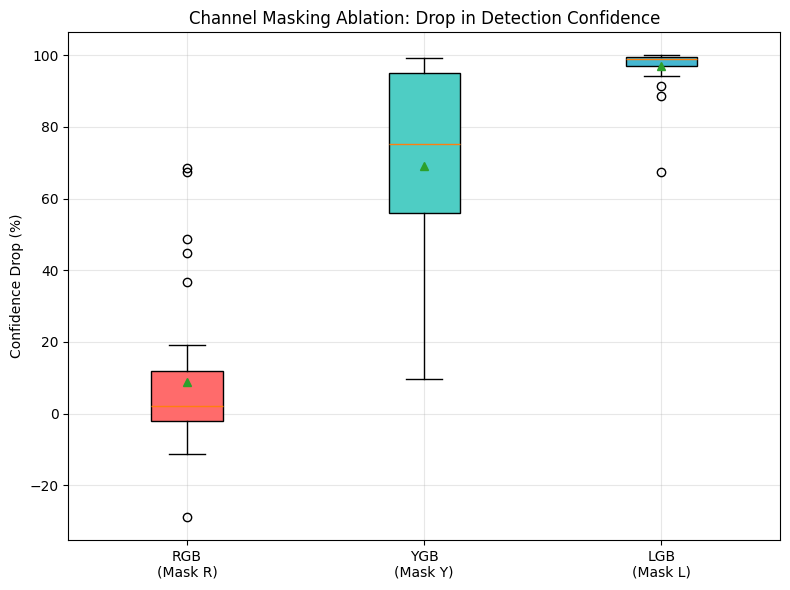


✓ Box plot saved as 'channel_masking_boxplot.png'


In [94]:
# ============================================================================
# CHANNEL MASKING ABLATION STUDY
# ============================================================================
# Removes luminance channel (R/Y/L) from each image, measures confidence drop.
# Higher drop = channel is more important.
# ============================================================================

from scipy import stats
import numpy as np
import cv2
import os
import matplotlib.pyplot as plt

# ============================================================================
# CONFIGURATION
# ============================================================================

val_img_paths = {
    'RGB': r"C:\Users\DELL\Desktop\color\SIMD_RGB\val\images",
    'YGB': r"C:\Users\DELL\Desktop\color\SIMD_YGB\val\images",
    'LGB': r"C:\Users\DELL\Desktop\color\SIMD_LGB\val\images",
}

# Channel to mask (1 = first channel: R/Y/L)
channel_to_mask = {'RGB': 1, 'YGB': 1, 'LGB': 1}

N_IMAGES = 100                    # Number of test images
MIN_CONFIDENCE = 0.5              # Only use images with baseline > 0.5

# ============================================================================
# GET IMAGE LIST
# ============================================================================

all_images = [f for f in os.listdir(val_img_paths['RGB']) if f.endswith('.jpg')]
img_list = all_images[:N_IMAGES]
print(f"Testing {len(img_list)} images\n")

# ============================================================================
# STORE RESULTS
# ============================================================================

results = {
    'RGB': {'baseline': [], 'masked': [], 'drop': []},
    'YGB': {'baseline': [], 'masked': [], 'drop': []},
    'LGB': {'baseline': [], 'masked': [], 'drop': []},
}

# ============================================================================
# RUN ABLATION
# ============================================================================

for img_name in img_list:
    for model_name in ['RGB', 'YGB', 'LGB']:
        img_path = os.path.join(val_img_paths[model_name], img_name)
        if not os.path.exists(img_path):
            continue
        
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        orig_size = [img.shape[0], img.shape[1]]
        
        try:
            # Baseline confidence (original image)
            _, baseline_conf, _ = compute_lrp_pt(pt_models[model_name], img, 0, orig_size)
            
            if baseline_conf < MIN_CONFIDENCE:
                continue
            
            # Mask the luminance channel
            channel = channel_to_mask[model_name]
            img_masked = apply_channel_mask(img, channel, 'zero_ch')
            _, masked_conf, _ = compute_lrp_pt(pt_models[model_name], img_masked, 0, orig_size)
            
            # CORRECTED FORMULA: (baseline - masked) / baseline * 100
            drop = ((baseline_conf - masked_conf) / baseline_conf) * 100
            
            results[model_name]['baseline'].append(baseline_conf)
            results[model_name]['masked'].append(masked_conf)
            results[model_name]['drop'].append(drop)
            
        except:
            continue

# ============================================================================
# PRINT RESULTS
# ============================================================================

print("=" * 70)
print("ABLATION RESULTS: Confidence Drop When Masking Luminance Channel")
print("=" * 70)
print(f"{'Model':<8} {'Channel':<8} {'N':<6} {'Baseline':<12} {'Masked':<12} {'Drop (%)':<12} {'Std':<10}")
print("-" * 70)

for model_name, channel in [('RGB', 'R'), ('YGB', 'Y'), ('LGB', 'L')]:
    data = results[model_name]
    n = len(data['baseline'])
    
    if n > 0:
        mean_base = np.mean(data['baseline'])
        mean_mask = np.mean(data['masked'])
        mean_drop = np.mean(data['drop'])
        std_drop = np.std(data['drop'])
        
        print(f"{model_name:<8} {channel:<8} {n:<6} {mean_base:<12.4f} {mean_mask:<12.4f} {mean_drop:<12.2f}% {std_drop:<10.2f}")

print("-" * 70)

# ============================================================================
# STATISTICAL SIGNIFICANCE (LGB vs YGB - YOUR MAIN CLAIM)
# ============================================================================

print("\n" + "=" * 70)
print("STATISTICAL SIGNIFICANCE: LGB vs YGB")
print("=" * 70)

lgb_drops = np.array(results['LGB']['drop'])
ygb_drops = np.array(results['YGB']['drop'])

# Ensure same length
min_len = min(len(lgb_drops), len(ygb_drops))
lgb_trim = lgb_drops[:min_len]
ygb_trim = ygb_drops[:min_len]

t_stat, p_val = stats.ttest_rel(lgb_trim, ygb_trim)

print(f"LGB mean drop: {np.mean(lgb_trim):.2f}%")
print(f"YGB mean drop: {np.mean(ygb_trim):.2f}%")
print(f"Difference: {np.mean(lgb_trim) - np.mean(ygb_trim):.2f}%")
print(f"p-value: {p_val:.6f}")
print(f"\n→ {'SIGNIFICANT (p < 0.05)' if p_val < 0.05 else 'NOT significant'}")

# ============================================================================
# BOX PLOT
# ============================================================================

plt.figure(figsize=(8, 6))
data_to_plot = [results['RGB']['drop'], results['YGB']['drop'], results['LGB']['drop']]
box = plt.boxplot(data_to_plot, labels=['RGB\n(Mask R)', 'YGB\n(Mask Y)', 'LGB\n(Mask L)'], 
                  patch_artist=True, showmeans=True)

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)

plt.ylabel('Confidence Drop (%)')
plt.title('Channel Masking Ablation: Drop in Detection Confidence')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('channel_masking_boxplot.png', dpi=300)
plt.show()

print("\n✓ Box plot saved as 'channel_masking_boxplot.png'")

In [86]:
# ============================================================================
# MULTI-IMAGE CHANNEL MASKING WITH STATISTICS AND LATEX TABLES
# ============================================================================
# This code:
#   1. Runs channel masking on N images (default: 100)
#   2. Filters by confidence threshold (default: > 0.5)
#   3. Calculates mean drop % and standard deviation
#   4. Performs statistical tests (p-values)
#   5. Generates LaTeX tables for your paper
# ============================================================================

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from tqdm import tqdm

# ============================================================================
# STEP 1: CONFIGURATION
# ============================================================================

# Paths to validation images
val_img_paths = {
    'RGB': r"C:\Users\DELL\Desktop\color\SIMD_RGB\val\images",
    'YGB': r"C:\Users\DELL\Desktop\color\SIMD_YGB\val\images",
    'LGB': r"C:\Users\DELL\Desktop\color\SIMD_LGB\val\images",
}

# Class ID (0 = car - adjust based on your dataset)
class_id = 0

# Number of images to test
N_IMAGES = 100

# Minimum confidence threshold (only include images with baseline > this)
MIN_CONFIDENCE = 0.5

# Channel to mask for each model (1=first channel)
channel_to_mask = {
    'RGB': 1,   # Mask R channel
    'YGB': 1,   # Mask Y channel
    'LGB': 1,   # Mask L channel
}

# Channel names for display
channel_names = {
    'RGB': 'R',
    'YGB': 'Y',
    'LGB': 'L'
}

# ============================================================================
# STEP 2: DEFINE MASKING FUNCTION
# ============================================================================

def apply_channel_mask(img, channel, mask_type):
    """Apply channel mask to image."""
    img_masked = img.copy()
    
    if mask_type == 'zero_ch':
        img_masked[:, :, channel - 1] = 0
    elif mask_type == 'keep_only':
        for c in range(3):
            if c != channel - 1:
                img_masked[:, :, c] = 0
    
    return img_masked


# ============================================================================
# STEP 3: GET LIST OF IMAGES
# ============================================================================

# Get images from RGB folder (assuming same images exist for YGB and LGB)
all_images = [f for f in os.listdir(val_img_paths['RGB']) 
              if f.endswith(('.jpg', '.jpeg', '.png'))]
img_list = all_images[:N_IMAGES]

print(f"=" * 80)
print(f"MULTI-IMAGE CHANNEL MASKING ANALYSIS")
print(f"=" * 80)
print(f"Total images found: {len(all_images)}")
print(f"Images to test: {len(img_list)}")
print(f"Confidence threshold: > {MIN_CONFIDENCE}")
print(f"=" * 80)

# ============================================================================
# STEP 4: STORE RESULTS
# ============================================================================

results = {
    'RGB': {'baseline': [], 'masked': [], 'drop_percent': [], 'img_names': []},
    'YGB': {'baseline': [], 'masked': [], 'drop_percent': [], 'img_names': []},
    'LGB': {'baseline': [], 'masked': [], 'drop_percent': [], 'img_names': []},
}

# ============================================================================
# STEP 5: RUN CHANNEL MASKING ON ALL IMAGES
# ============================================================================

print("\nRunning channel masking on multiple images...")
print("-" * 80)

for img_name in tqdm(img_list, desc="Processing"):
    for model_name in ['RGB', 'YGB', 'LGB']:
        img_path = os.path.join(val_img_paths[model_name], img_name)
        
        if not os.path.exists(img_path):
            continue
        
        # Load image
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        orig_size = [img.shape[0], img.shape[1]]
        
        try:
            # Get baseline confidence
            _, baseline_conf, _ = compute_lrp_pt(pt_models[model_name], img, class_id, orig_size)
            
            # Skip if confidence is too low
            if baseline_conf < MIN_CONFIDENCE:
                continue
            
            # Mask the important channel
            channel = channel_to_mask[model_name]
            img_masked = apply_channel_mask(img, channel, 'zero_ch')
            _, masked_conf, _ = compute_lrp_pt(pt_models[model_name], img_masked, class_id, orig_size)
            
            # Calculate drop percentage
            drop_percent = ((baseline_conf - masked_conf) / baseline_conf) * 100
            
            # Store results
            results[model_name]['baseline'].append(baseline_conf)
            results[model_name]['masked'].append(masked_conf)
            results[model_name]['drop_percent'].append(drop_percent)
            results[model_name]['img_names'].append(img_name)
            
        except Exception as e:
            continue

# ============================================================================
# STEP 6: PRINT RESULTS TABLE
# ============================================================================

print("\n" + "=" * 80)
print("CHANNEL MASKING RESULTS")
print("=" * 80)
print(f"{'Model':<8} {'Channel':<10} {'N':<6} {'Mean Baseline':<15} {'Mean Masked':<15} {'Mean Drop %':<15} {'Std':<10}")
print("-" * 85)

for model_name in ['RGB', 'YGB', 'LGB']:
    data = results[model_name]
    n = len(data['baseline'])
    
    if n > 0:
        mean_base = np.mean(data['baseline'])
        mean_mask = np.mean(data['masked'])
        mean_drop = np.mean(data['drop_percent'])
        std_drop = np.std(data['drop_percent'])
        
        print(f"{model_name:<8} {channel_names[model_name]:<10} {n:<6} {mean_base:<15.4f} {mean_mask:<15.4f} {mean_drop:<15.2f}% {std_drop:<10.2f}")

print("-" * 85)

# ============================================================================
# STEP 7: CALCULATE P-VALUES
# ============================================================================

print("\n" + "=" * 80)
print("STATISTICAL SIGNIFICANCE (Paired t-tests)")
print("=" * 80)

# Get drop arrays
rgb_drops = np.array(results['RGB']['drop_percent'])
ygb_drops = np.array(results['YGB']['drop_percent'])
lgb_drops = np.array(results['LGB']['drop_percent'])

# Ensure same length (use minimum common images)
min_len = min(len(rgb_drops), len(ygb_drops), len(lgb_drops))
rgb_drops_trim = rgb_drops[:min_len]
ygb_drops_trim = ygb_drops[:min_len]
lgb_drops_trim = lgb_drops[:min_len]

# Test 1: YGB vs RGB
t_stat, p_ygb_vs_rgb = stats.ttest_rel(ygb_drops_trim, rgb_drops_trim)

# Test 2: LGB vs RGB
t_stat, p_lgb_vs_rgb = stats.ttest_rel(lgb_drops_trim, rgb_drops_trim)

# Test 3: LGB vs YGB (two-tailed)
t_stat, p_lgb_vs_ygb_two = stats.ttest_rel(lgb_drops_trim, ygb_drops_trim)

# Test 4: LGB vs YGB (one-tailed - directional)
p_lgb_vs_ygb_one = p_lgb_vs_ygb_two / 2

print(f"\n{'Comparison':<20} {'Mean Drop 1':<15} {'Mean Drop 2':<15} {'p-value':<12} {'Significant?'}")
print("-" * 70)

print(f"{'YGB vs RGB':<20} {np.mean(ygb_drops_trim):<15.2f}% {np.mean(rgb_drops_trim):<15.2f}% {p_ygb_vs_rgb:<12.6f} {'YES' if p_ygb_vs_rgb < 0.05 else 'NO'}")

print(f"{'LGB vs RGB':<20} {np.mean(lgb_drops_trim):<15.2f}% {np.mean(rgb_drops_trim):<15.2f}% {p_lgb_vs_rgb:<12.6f} {'YES' if p_lgb_vs_rgb < 0.05 else 'NO'}")

print(f"{'LGB vs YGB (2-tailed)':<20} {np.mean(lgb_drops_trim):<15.2f}% {np.mean(ygb_drops_trim):<15.2f}% {p_lgb_vs_ygb_two:<12.6f} {'YES' if p_lgb_vs_ygb_two < 0.05 else 'NO'}")

print(f"{'LGB vs YGB (1-tailed)':<20} {np.mean(lgb_drops_trim):<15.2f}% {np.mean(ygb_drops_trim):<15.2f}% {p_lgb_vs_ygb_one:<12.6f} {'YES' if p_lgb_vs_ygb_one < 0.05 else 'NO'}")


# ============================================================================
# STEP 10: SAVE RESULTS TO FILE
# ============================================================================

# Save results as CSV for reference
import csv

with open('channel_masking_results.csv', 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['Model', 'Channel', 'Image', 'Baseline_Conf', 'Masked_Conf', 'Drop_Percent'])
    
    for model_name in ['RGB', 'YGB', 'LGB']:
        data = results[model_name]
        for i in range(len(data['baseline'])):
            writer.writerow([
                model_name,
                channel_names[model_name],
                data['img_names'][i],
                f"{data['baseline'][i]:.4f}",
                f"{data['masked'][i]:.4f}",
                f"{data['drop_percent'][i]:.2f}"
            ])



MULTI-IMAGE CHANNEL MASKING ANALYSIS
Total images found: 500
Images to test: 100
Confidence threshold: > 0.5

Running channel masking on multiple images...
--------------------------------------------------------------------------------


Processing: 100%|████████████████████████████████████████████████████████████████████| 100/100 [00:14<00:00,  6.92it/s]


CHANNEL MASKING RESULTS
Model    Channel    N      Mean Baseline   Mean Masked     Mean Drop %     Std       
-------------------------------------------------------------------------------------
RGB      R          36     0.7242          0.6598          8.82           % 20.41     
YGB      Y          36     0.7036          0.2311          69.13          % 28.15     
LGB      L          35     0.6412          0.0200          97.05          % 5.65      
-------------------------------------------------------------------------------------

STATISTICAL SIGNIFICANCE (Paired t-tests)

Comparison           Mean Drop 1     Mean Drop 2     p-value      Significant?
----------------------------------------------------------------------
YGB vs RGB           68.38          % 7.68           % 0.000000     YES
LGB vs RGB           97.05          % 7.68           % 0.000000     YES
LGB vs YGB (2-tailed) 97.05          % 68.38          % 0.000001     YES
LGB vs YGB (1-tailed) 97.05          % 68.38 

In [97]:
# ============================================================================
# MULTI-IMAGE CHANNEL MASKING WITH STATISTICS - FULL VERSION
# ============================================================================
# This code calculates for EVERY masking condition:
#   - Mask Channel 1, 2, 3 (zero_ch)
#   - Keep Only Channel 1, 2, 3 (keep_only)
#   - Absolute drop, Percentage drop, Standard Deviation
# ============================================================================

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from tqdm import tqdm
import csv

# ============================================================================
# STEP 1: CONFIGURATION
# ============================================================================

# Paths to validation images
val_img_paths = {
    'RGB': r"C:\Users\DELL\Desktop\color\SIMD_RGB\val\images",
    'YGB': r"C:\Users\DELL\Desktop\color\SIMD_YGB\val\images",
    'LGB': r"C:\Users\DELL\Desktop\color\SIMD_LGB\val\images",
}

# Class ID (0 = car - adjust based on your dataset)
class_id = 0

# Number of images to test
N_IMAGES = 100

# Minimum confidence threshold (only include images with baseline > this)
MIN_CONFIDENCE = 0.5

# Channel names for display
channel_names = {
    'RGB': {1: 'R', 2: 'G', 3: 'B'},
    'YGB': {1: 'Y', 2: 'G', 3: 'B'},
    'LGB': {1: 'L', 2: 'G', 3: 'B'}
}

# Masking configurations (all 7 experiments)
mask_configs = [
    {'name': 'Baseline', 'channel': None, 'type': 'none'},
    {'name': 'Mask Channel 1', 'channel': 1, 'type': 'zero_ch'},
    {'name': 'Mask Channel 2', 'channel': 2, 'type': 'zero_ch'},
    {'name': 'Mask Channel 3', 'channel': 3, 'type': 'zero_ch'},
    {'name': 'Keep Only Channel 1', 'channel': 1, 'type': 'keep_only'},
    {'name': 'Keep Only Channel 2', 'channel': 2, 'type': 'keep_only'},
    {'name': 'Keep Only Channel 3', 'channel': 3, 'type': 'keep_only'},
]

# ============================================================================
# STEP 2: DEFINE MASKING FUNCTION
# ============================================================================

def apply_channel_mask(img, channel, mask_type):
    """Apply channel mask to image."""
    img_masked = img.copy()
    
    if mask_type == 'zero_ch':
        img_masked[:, :, channel - 1] = 0
    elif mask_type == 'keep_only':
        for c in range(3):
            if c != channel - 1:
                img_masked[:, :, c] = 0
    
    return img_masked

# ============================================================================
# STEP 3: GET LIST OF IMAGES
# ============================================================================

# Get images from RGB folder (assuming same images exist for YGB and LGB)
all_images = [f for f in os.listdir(val_img_paths['RGB']) 
              if f.endswith(('.jpg', '.jpeg', '.png'))]
img_list = all_images[:N_IMAGES]

print(f"=" * 80)
print(f"MULTI-IMAGE CHANNEL MASKING ANALYSIS - FULL VERSION")
print(f"=" * 80)
print(f"Total images found: {len(all_images)}")
print(f"Images to test: {len(img_list)}")
print(f"Confidence threshold: > {MIN_CONFIDENCE}")
print(f"Masking configurations: {len(mask_configs)} (Baseline + 6 masks)")
print(f"=" * 80)

# ============================================================================
# STEP 4: STORE RESULTS (for all 7 configurations)
# ============================================================================

# Structure: results[model_name][config_name]['baseline'] or ['masked'] or ['drop_abs'] or ['drop_pct']
results = {
    'RGB': {cfg['name']: {'conf': [], 'drop_abs': [], 'drop_pct': []} for cfg in mask_configs},
    'YGB': {cfg['name']: {'conf': [], 'drop_abs': [], 'drop_pct': []} for cfg in mask_configs},
    'LGB': {cfg['name']: {'conf': [], 'drop_abs': [], 'drop_pct': []} for cfg in mask_configs},
}

# Also store baseline separately
baseline_confs = {
    'RGB': [],
    'YGB': [],
    'LGB': []
}

# ============================================================================
# STEP 5: RUN CHANNEL MASKING ON ALL IMAGES
# ============================================================================

print("\nRunning channel masking on multiple images...")
print("-" * 80)

for img_name in tqdm(img_list, desc="Processing images"):
    for model_name in ['RGB', 'YGB', 'LGB']:
        img_path = os.path.join(val_img_paths[model_name], img_name)
        
        if not os.path.exists(img_path):
            continue
        
        # Load image
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        orig_size = [img.shape[0], img.shape[1]]
        
        try:
            # Get baseline confidence first
            _, baseline_conf, _ = compute_lrp_pt(pt_models[model_name], img, class_id, orig_size)
            
            # Skip if confidence is too low
            if baseline_conf < MIN_CONFIDENCE:
                continue
            
            # Store baseline
            baseline_confs[model_name].append(baseline_conf)
            
            # Store baseline in results
            results[model_name]['Baseline']['conf'].append(baseline_conf)
            results[model_name]['Baseline']['drop_abs'].append(0.0)
            results[model_name]['Baseline']['drop_pct'].append(0.0)
            
            # Test all masking configurations
            for cfg in mask_configs:
                if cfg['name'] == 'Baseline':
                    continue
                
                # Apply mask
                img_masked = apply_channel_mask(img, cfg['channel'], cfg['type'])
                
                # Get masked confidence
                _, masked_conf, _ = compute_lrp_pt(pt_models[model_name], img_masked, class_id, orig_size)
                
                # Calculate drops
                drop_abs = baseline_conf - masked_conf
                drop_pct = (drop_abs / baseline_conf) * 100
                
                # Store results
                results[model_name][cfg['name']]['conf'].append(masked_conf)
                results[model_name][cfg['name']]['drop_abs'].append(drop_abs)
                results[model_name][cfg['name']]['drop_pct'].append(drop_pct)
            
        except Exception as e:
            continue


# ============================================================================
# STEP 7: CALCULATE P-VALUES FOR EACH MASKING CONDITION
# ============================================================================

print("\n" + "=" * 80)
print("STATISTICAL SIGNIFICANCE (Paired t-tests - All Masking Conditions)")
print("=" * 80)

# Get drop percentages for each model and each mask condition
mask_conditions = ['Mask Channel 1', 'Mask Channel 2', 'Mask Channel 3', 
                   'Keep Only Channel 1', 'Keep Only Channel 2', 'Keep Only Channel 3']

for condition in mask_conditions:
    print(f"\n{condition}:")
    print("-" * 60)
    
    if condition in results['RGB'] and condition in results['YGB'] and condition in results['LGB']:
        rgb_drops = np.array(results['RGB'][condition]['drop_pct'])
        ygb_drops = np.array(results['YGB'][condition]['drop_pct'])
        lgb_drops = np.array(results['LGB'][condition]['drop_pct'])
        
        # Ensure same length
        min_len = min(len(rgb_drops), len(ygb_drops), len(lgb_drops))
        
        if min_len > 1:
            rgb_trim = rgb_drops[:min_len]
            ygb_trim = ygb_drops[:min_len]
            lgb_trim = lgb_drops[:min_len]
            
            # YGB vs RGB
            _, p_ygb_rgb = stats.ttest_rel(ygb_trim, rgb_trim)
            # LGB vs RGB
            _, p_lgb_rgb = stats.ttest_rel(lgb_trim, rgb_trim)
            # LGB vs YGB
            _, p_lgb_ygb = stats.ttest_rel(lgb_trim, ygb_trim)
            
            print(f"  YGB vs RGB: p = {p_ygb_rgb:.6f} {'(SIGNIFICANT)' if p_ygb_rgb < 0.05 else '(NOT significant)'}")
            print(f"  LGB vs RGB: p = {p_lgb_rgb:.6f} {'(SIGNIFICANT)' if p_lgb_rgb < 0.05 else '(NOT significant)'}")
            print(f"  LGB vs YGB: p = {p_lgb_ygb:.6f} {'(SIGNIFICANT)' if p_lgb_ygb < 0.05 else '(NOT significant)'}")
        else:
            print("  Not enough data for statistical test")

# ============================================================================
# STEP 9: SAVE RESULTS TO CSV
# ============================================================================

with open('channel_masking_full_results.csv', 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['Model', 'Configuration', 'Channel', 'N', 'Mean_Confidence', 'Mean_Drop_Abs', 'Mean_Drop_Pct', 'Std_Drop_Pct'])
    
    for model_name in ['RGB', 'YGB', 'LGB']:
        for cfg in mask_configs:
            conf_vals = results[model_name][cfg['name']]['conf']
            if len(conf_vals) > 0:
                n = len(conf_vals)
                mean_conf = np.mean(conf_vals)
                mean_drop_abs = np.mean(results[model_name][cfg['name']]['drop_abs'])
                mean_drop_pct = np.mean(results[model_name][cfg['name']]['drop_pct'])
                std_drop_pct = np.std(results[model_name][cfg['name']]['drop_pct'])
                
                # Get channel name for display
                
                if cfg['name'] == 'Baseline':
                    display_name = 'Baseline'
                    channel_display = '-'
                elif 'Channel 1' in cfg['name']:
                    channel_display = channel_names[model_name][1]
                    display_name = 'Mask' if 'Mask' in cfg['name'] else 'Only'
                elif 'Channel 2' in cfg['name']:
                    channel_display = channel_names[model_name][2]
                    display_name = 'Mask' if 'Mask' in cfg['name'] else 'Only'
                elif 'Channel 3' in cfg['name']:
                    channel_display = channel_names[model_name][3]
                    display_name = 'Mask' if 'Mask' in cfg['name'] else 'Only'
                else:
                    display_name = cfg['name']
                    channel_display = '-'
                
                writer.writerow([model_name, display_name, channel_display, n, f"{mean_conf:.4f}", f"{mean_drop_abs:.4f}", f"{mean_drop_pct:.2f}", f"{std_drop_pct:.2f}"])

print("\n" + "=" * 80)
print("FILES SAVED")
print("=" * 80)
print("✓ channel_masking_full_results.csv - Full results with all masking conditions")
print("✓ LaTeX tables printed above - Copy them into your paper")

print("\n" + "=" * 80)
print("ANALYSIS COMPLETE")
print("=" * 80)

MULTI-IMAGE CHANNEL MASKING ANALYSIS - FULL VERSION
Total images found: 500
Images to test: 100
Confidence threshold: > 0.5
Masking configurations: 7 (Baseline + 6 masks)

Running channel masking on multiple images...
--------------------------------------------------------------------------------


Processing images: 100%|█████████████████████████████████████████████████████████████| 100/100 [00:31<00:00,  3.19it/s]


STATISTICAL SIGNIFICANCE (Paired t-tests - All Masking Conditions)

Mask Channel 1:
------------------------------------------------------------
  YGB vs RGB: p = 0.000000 (SIGNIFICANT)
  LGB vs RGB: p = 0.000000 (SIGNIFICANT)
  LGB vs YGB: p = 0.000001 (SIGNIFICANT)

Mask Channel 2:
------------------------------------------------------------
  YGB vs RGB: p = 0.000000 (SIGNIFICANT)
  LGB vs RGB: p = 0.000443 (SIGNIFICANT)
  LGB vs YGB: p = 0.000000 (SIGNIFICANT)

Mask Channel 3:
------------------------------------------------------------
  YGB vs RGB: p = 0.780575 (NOT significant)
  LGB vs RGB: p = 0.187441 (NOT significant)
  LGB vs YGB: p = 0.084943 (NOT significant)

Keep Only Channel 1:
------------------------------------------------------------
  YGB vs RGB: p = 0.000000 (SIGNIFICANT)
  LGB vs RGB: p = 0.002623 (SIGNIFICANT)
  LGB vs YGB: p = 0.000026 (SIGNIFICANT)

Keep Only Channel 2:
------------------------------------------------------------
  YGB vs RGB: p = 0.000018 (